
=== Rep 1/5 ===


/home/eaves/Source/repos/MOGONET/utils.py:43: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1768417387920/work/torch/csrc/utils/tensor_new.cpp:654.)
  return sparse_tensortype(indices, values, x.size())



Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.205
Test: Epoch 50  ACC 0.707
Test: Epoch 100  ACC 0.764
Test: Epoch 150  ACC 0.776
Test: Epoch 200  ACC 0.779
Test: Epoch 250  ACC 0.795
Test: Epoch 300  ACC 0.787
Test: Epoch 350  ACC 0.787
Test: Epoch 400  ACC 0.764
Test: Epoch 450  ACC 0.810
Test: Epoch 500  ACC 0.791

=== Rep 2/5 ===

Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.240
Test: Epoch 50  ACC 0.730
Test: Epoch 100  ACC 0.798
Test: Epoch 150  ACC 0.779
Test: Epoch 200  ACC 0.791
Test: Epoch 250  ACC 0.802
Test: Epoch 300  ACC 0.802
Test: Epoch 350  ACC 0.787
Test: Epoch 400  ACC 0.791
Test: Epoch 450  ACC 0.779
Test: Epoch 500  ACC 0.791

=== Rep 3/5 ===

Pretrain GCNs...

Training...
Test: Epoch 0  ACC 0.183
Test: Epoch 50  ACC 0.665
Test: Epoch 100  ACC 0.741
Test: Epoch 150  ACC 0.779
Test: Epoch 200  ACC 0.757
Test: Epoch 250  ACC 0.768
Test: Epoch 300  ACC 0.776
Test: Epoch 350  ACC 0.795
Test: Epoch 400  ACC 0.772
Test: Epoch 450  ACC 0.783
Test: Epoch 500  A

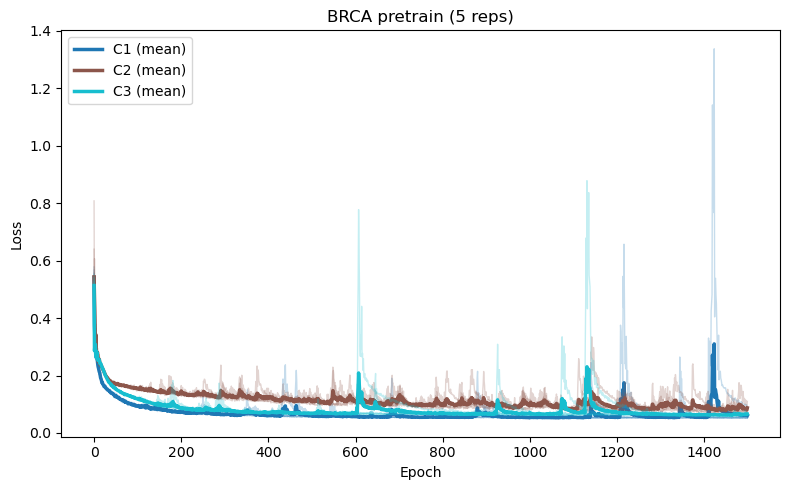

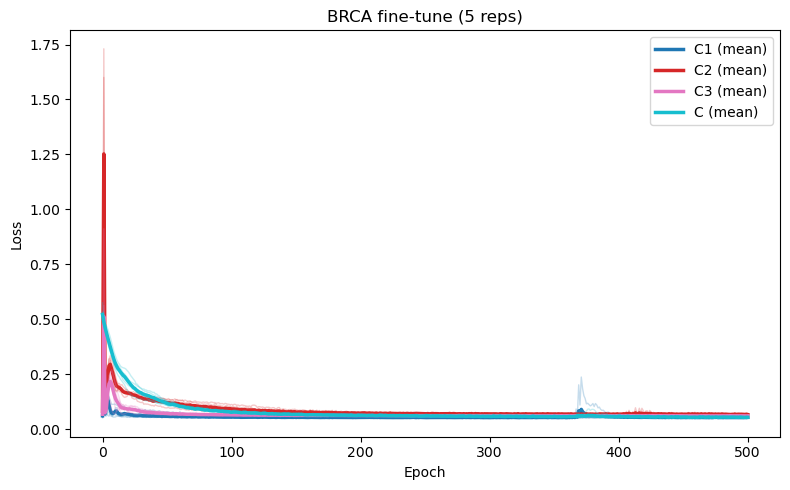

In [ ]:
from mogonet_training_logger import run_reps_with_history, plot_phase_histories

pretrain_histories, finetune_histories = run_reps_with_history(
    data_folder="BRCA", # change to ROSMAP if needed
    view_list=[1, 2, 3],
    num_class=5, # set to 2 if training on ROSMAP
    lr_e_pretrain=1e-3,
    lr_e=5e-4,
    lr_c=1e-3,
    num_epoch_pretrain=1500,
    num_epoch=500,
    num_reps=5,
    model_folder="BRCA/models",  # set to None to skip saving
)

plot_phase_histories(pretrain_histories, phase_name="Pretrain", title="BRCA pretrain (5 reps)")
plot_phase_histories(finetune_histories, phase_name="Fine-tune", title="BRCA fine-tune (5 reps)")

In [9]:
import os
import copy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from cal_perf_metrics import cal_test_metrics
from train_test import train_test

def run_cross_validation(data_folder, view_list, num_class, num_splits=5):
    all_auc, all_acc, all_bacc, all_f1 = [], [], [], []
    all_precision, all_recall, all_se, all_sp = [], [], [], []

    for i in range(num_splits):
        print(f"Run {i+1}/{num_splits}...")

        # train_test(
        #     data_folder, view_list, num_class,
        #     lr_e_pretrain=1e-3, lr_e=5e-4, lr_c=1e-3,
        #     num_epoch_pretrain=1500, num_epoch=500
        # )

        model_folder = os.path.join(data_folder, 'models')
        rep_folder = os.path.join(model_folder, str(i + 1)) if model_folder else None

        # Performance metrics    
        m = cal_test_metrics(data_folder, rep_folder, view_list, num_class)
        all_auc.append(m["auc"])
        all_acc.append(m["acc"])
        all_bacc.append(m["bacc"])
        all_f1.append(m["f1"])
        all_precision.append(m["precision"])
        all_recall.append(m["recall"])
        all_se.append(m["sensitivity"])
        all_sp.append(m["specificity"])

    return all_auc, all_acc, all_bacc, all_f1, all_precision, all_recall, all_se, all_sp

def plot_results(data_folder, all_metrics, output_dir="results"):
    os.makedirs(output_dir, exist_ok=True)
    output_dir = os.path.join(data_folder, output_dir)
    
    metric_names = ["AUC", "Accuracy", "BalAccuracy", "F1", "Precision", "Recall", "Sensitivity", "Specificity"]
    for metric, name in zip(all_metrics, metric_names):
        sns.histplot(metric, kde=True)
        plt.title(f"{name} Distribution")
        plt.savefig(os.path.join(output_dir, f"{name}_MOGONET_reps.png"))
        plt.clf()

    # Save mean performances
    mean_perf = {name.lower(): np.mean(metric) for name, metric in zip(metric_names, all_metrics)}
    with open(os.path.join(output_dir, "MeanPerf_MOGONET_reps.txt"), "w") as f:
        for key, value in mean_perf.items():
            f.write(f"{key}: {value}\n")

In [12]:
if __name__ == "__main__":
    data_folder = 'BRCA'  # Change to 'ROSMAP' if needed
    view_list = [1, 2, 3]
    num_class = 5 if data_folder == 'BRCA' else 2

    all_metrics = run_cross_validation(data_folder, view_list, num_class)
    plot_results(data_folder, all_metrics)

Run 1/5...
Run 2/5...
Run 3/5...
Run 4/5...
Run 5/5...


<Figure size 640x480 with 0 Axes>

Displaying AUC_MOGONET_reps.png


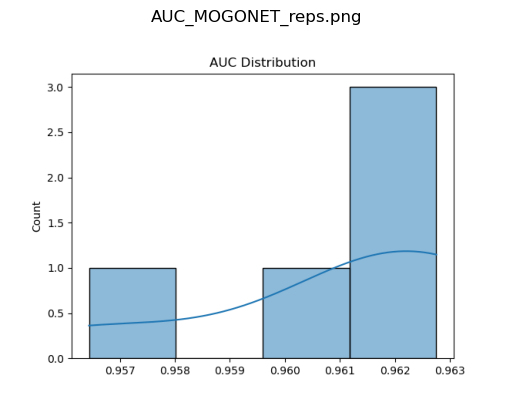

Displaying F1_MOGONET_reps.png


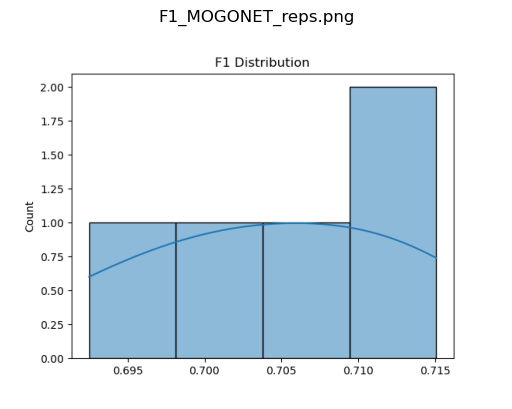

Displaying Precision_MOGONET_reps.png


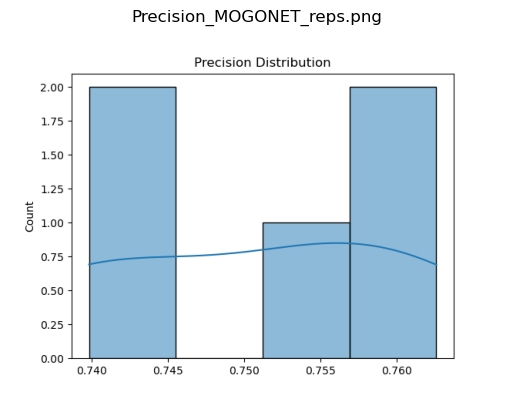

Displaying BalAccuracy_MOGONET_reps.png


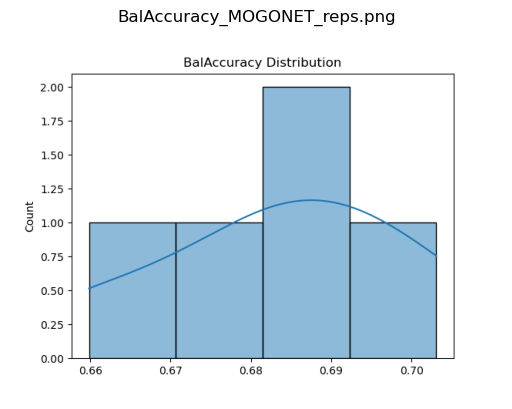

Displaying Specificity_MOGONET_reps.png


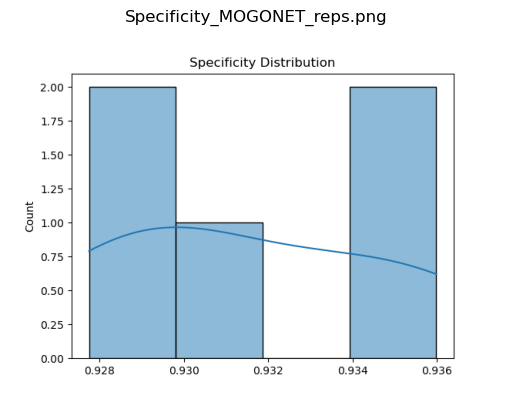

Displaying Recall_MOGONET_reps.png


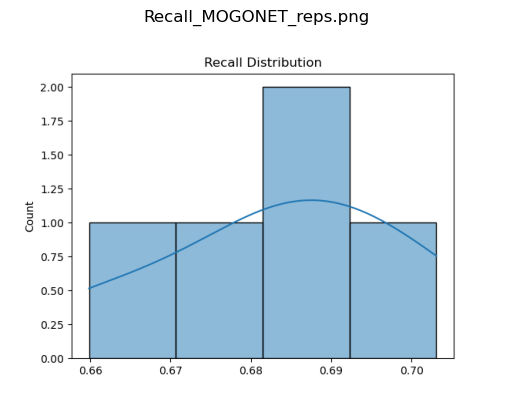

Displaying Accuracy_MOGONET_reps.png


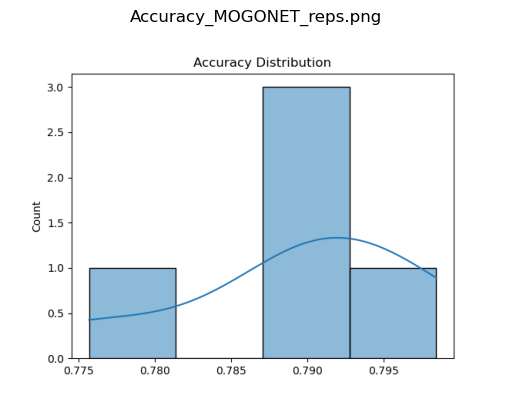

Displaying Sensitivity_MOGONET_reps.png


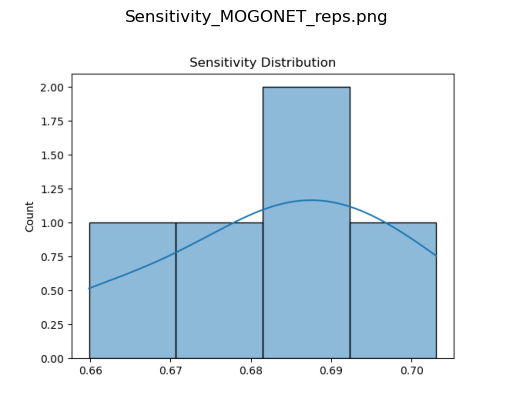

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# Path to the results folder
data_folder = "BRCA"
results_dir = "results"
results_dir = os.path.join(data_folder, results_dir)

# List all image files in the folder
image_files = glob.glob(os.path.join(results_dir, "*.png"))

# Check if any files were found
if not image_files:
    print("No images found in the results folder.")
else:
    # Display each image one by one
    for img_path in image_files:
        print(f"Displaying {os.path.basename(img_path)}")
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')  # Remove axes for better visualization
        plt.title(os.path.basename(img_path))  # Add title with filename
        plt.show()


Rank	Feature name
1	GPR37L1
2	MIR563
3	TMEM207
4	C3orf16
5	OR1J4
6	SIRPD
7	ATP10B
8	KRTAP3-1
9	TM4SF18
10	AGR2
11	ASF1A
12	REP15
13	CDH26
14	IGFALS
15	PROM1
16	MT1DP
17	AGR3
18	LOC145837
19	SPOCK2
20	MIR645
21	OR10P1
22	GALT
23	RALB
24	FLJ41941
25	PA2G4P4
26	C21orf15
27	PCDHB8
28	RUSC2
29	LOC100130264
30	MORN3


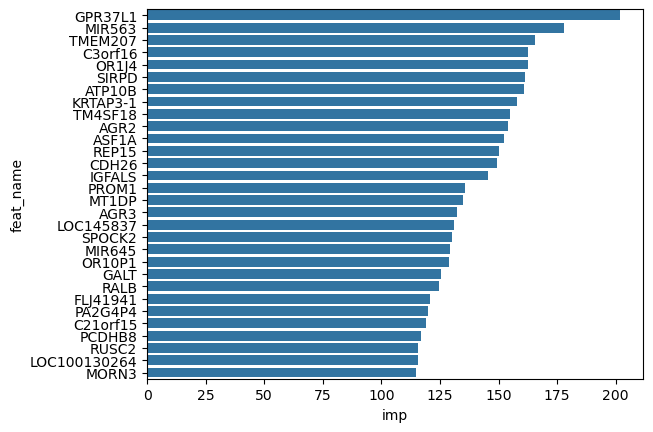

In [16]:
""" Example for biomarker identification
"""
import os
import copy
from feat_importance import cal_feat_imp, summarize_imp_feat

if __name__ == "__main__":
    data_folder = 'BRCA'
    model_folder = os.path.join(data_folder, 'models')
    view_list = [1,2,3]
    if data_folder == 'ROSMAP':
        num_class = 2
    if data_folder == 'BRCA':
        num_class = 5

    featimp_list_list = []
    for rep in range(5):
        featimp_list = cal_feat_imp(data_folder, os.path.join(model_folder, str(rep+1)), 
                                    view_list, num_class)
        featimp_list_list.append(copy.deepcopy(featimp_list))

    output_dir = os.path.join(data_folder, "results")

    df_featimp_top = summarize_imp_feat(featimp_list_list)
    df_featimp_top.to_csv(os.path.join(output_dir, "FeatImp.csv"), index=False)
    feat_imp_plot = sns.barplot(data=df_featimp_top, x="imp", y="feat_name")
    feat_imp_plot.get_figure().savefig(os.path.join(output_dir, "Feature_imp_MOGONET.png"))
    